# Predictive Maintenance: Data Pipeline and Anomaly Detection
Trained in Google Colab on the UCI AI4I 2020 dataset (synthetic, 10,000 records). Run the cells in order. The notebook produces `model_bundle.joblib`, `metrics.json` and `pr_curves.png`, which the Flask app uses.

In [1]:
!pip install -q ucimlrepo

## 1. Ingestion and validation
Column standardisation, null/duplicate/range checks, and a label-consistency check.

In [2]:
import re
import sqlite3
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo

# ---------- 1. Ingest ----------
dataset = fetch_ucirepo(id=601)  # AI4I 2020 Predictive Maintenance Dataset
raw = dataset.data.original.copy()
print("Raw shape:", raw.shape)
print("Raw columns:", raw.columns.tolist())

# ---------- 2. Standardise column names (drop units, snake_case) ----------
def normalize(col: str) -> str:
    col = re.sub(r"\[.*?\]", "", col)          # remove units such as [K]
    col = col.strip().lower()
    return re.sub(r"[^a-z0-9]+", "_", col).strip("_")

df = raw.rename(columns=normalize)
if "uid" in df.columns:                         # some versions use UID instead of UDI
    df = df.rename(columns={"uid": "udi"})

SENSOR_COLS = ["air_temperature", "process_temperature",
               "rotational_speed", "torque", "tool_wear"]
LABEL_COLS = ["machine_failure", "twf", "hdf", "pwf", "osf", "rnf"]
REQUIRED = ["udi", "product_id", "type"] + SENSOR_COLS + LABEL_COLS

missing = [c for c in REQUIRED if c not in df.columns]
assert not missing, f"Missing expected columns: {missing}"
df = df[REQUIRED].copy()

# ---------- 3. Validate ----------
report = {}
report["rows"] = len(df)
report["null_cells"] = int(df.isna().sum().sum())
report["duplicate_udi"] = int(df["udi"].duplicated().sum())
report["duplicate_product_id"] = int(df["product_id"].duplicated().sum())
report["unknown_types"] = int((~df["type"].isin(["L", "M", "H"])).sum())

# Loose physical sanity bounds (units: K, K, rpm, Nm, min)
bounds = {
    "air_temperature": (280, 320),
    "process_temperature": (290, 330),
    "rotational_speed": (500, 4000),
    "torque": (0, 100),
    "tool_wear": (0, 300),
}
for col, (lo, hi) in bounds.items():
    report[f"out_of_range_{col}"] = int(((df[col] < lo) | (df[col] > hi)).sum())

# Label consistency: machine_failure should equal "any failure mode"
any_mode = df[["twf", "hdf", "pwf", "osf", "rnf"]].max(axis=1)
report["label_mismatch_rows"] = int((any_mode != df["machine_failure"]).sum())
report["failure_rate_pct"] = round(100 * df["machine_failure"].mean(), 2)

print("\n--- Validation report ---")
for k, v in report.items():
    print(f"{k:32s} {v}")

df.head()

Raw shape: (10000, 14)
Raw columns: ['UID', 'Product ID', 'Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

--- Validation report ---
rows                             10000
null_cells                       0
duplicate_udi                    0
duplicate_product_id             0
unknown_types                    0
out_of_range_air_temperature     0
out_of_range_process_temperature 0
out_of_range_rotational_speed    0
out_of_range_torque              0
out_of_range_tool_wear           0
label_mismatch_rows              27
failure_rate_pct                 3.39


,udi,product_id,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,machine_failure,twf,hdf,pwf,osf,rnf
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. SQL schema and feature engineering
Readings and failure labels in separate SQLite tables; derived features computed in SQL.

In [3]:
DB_PATH = "/content/maintenance.db"

conn = sqlite3.connect(DB_PATH)
cur = conn.cursor()

# Separate sensor readings from failure labels (normalised schema)
cur.executescript("""
DROP TABLE IF EXISTS failures;
DROP TABLE IF EXISTS readings;

CREATE TABLE readings (
    udi                  INTEGER PRIMARY KEY,
    product_id           TEXT NOT NULL,
    type                 TEXT NOT NULL CHECK (type IN ('L','M','H')),
    air_temperature      REAL NOT NULL,   -- K
    process_temperature  REAL NOT NULL,   -- K
    rotational_speed     REAL NOT NULL,   -- rpm
    torque               REAL NOT NULL,   -- Nm
    tool_wear            REAL NOT NULL    -- min
);

CREATE TABLE failures (
    udi             INTEGER PRIMARY KEY REFERENCES readings(udi),
    machine_failure INTEGER NOT NULL,
    twf INTEGER NOT NULL, hdf INTEGER NOT NULL, pwf INTEGER NOT NULL,
    osf INTEGER NOT NULL, rnf INTEGER NOT NULL
);

CREATE INDEX idx_readings_type ON readings(type);
""")

df[["udi", "product_id", "type"] + SENSOR_COLS].to_sql(
    "readings", conn, if_exists="append", index=False)
df[["udi"] + LABEL_COLS].to_sql(
    "failures", conn, if_exists="append", index=False)
conn.commit()

# ---------- Feature engineering done in SQL ----------
FEATURE_QUERY = """
SELECT
    r.udi,
    CASE r.type WHEN 'L' THEN 0 WHEN 'M' THEN 1 ELSE 2 END      AS type_code,
    r.air_temperature,
    r.process_temperature,
    r.process_temperature - r.air_temperature                   AS temp_diff,
    r.rotational_speed,
    r.torque,
    r.tool_wear,
    r.torque * r.rotational_speed * 2 * 3.141592653589793 / 60  AS power_w,
    r.torque * r.tool_wear                                      AS strain,
    f.machine_failure
FROM readings r
JOIN failures f USING (udi)
ORDER BY r.udi
"""
features = pd.read_sql_query(FEATURE_QUERY, conn)
print("Feature table:", features.shape)
display(features.head())

# ---------- A couple of analytical queries ----------
print("\nFailure rate by product quality type:")
display(pd.read_sql_query("""
    SELECT r.type,
           COUNT(*) AS n_records,
           SUM(f.machine_failure) AS n_failures,
           ROUND(100.0 * AVG(f.machine_failure), 2) AS failure_rate_pct
    FROM readings r JOIN failures f USING (udi)
    GROUP BY r.type
    ORDER BY failure_rate_pct DESC
""", conn))

print("\nFailures by mode:")
display(pd.read_sql_query("""
    SELECT SUM(twf) AS tool_wear, SUM(hdf) AS heat_dissipation,
           SUM(pwf) AS power, SUM(osf) AS overstrain, SUM(rnf) AS random_failure
    FROM failures
""", conn))

conn.close()

Feature table: (10000, 11)


,udi,type_code,air_temperature,process_temperature,temp_diff,rotational_speed,torque,tool_wear,power_w,strain,machine_failure
0,1,1,298.1,308.6,10.5,1551.0,42.8,0.0,6951.590560,0.0,0
1,2,0,298.2,308.7,10.5,1408.0,46.3,3.0,6826.722724,138.9,0
2,3,0,298.1,308.5,10.4,1498.0,49.4,5.0,7749.387543,247.0,0
3,4,0,298.2,308.6,10.4,1433.0,39.5,7.0,5927.504659,276.5,0
4,5,0,298.2,308.7,10.5,1408.0,40.0,9.0,5897.816608,360.0,0



Failure rate by product quality type:


,type,n_records,n_failures,failure_rate_pct
0,L,6000,235,3.92
1,M,2997,83,2.77
2,H,1003,21,2.09



Failures by mode:


,tool_wear,heat_dissipation,power,overstrain,random_failure
0,46,115,95,98,19


## 3. Models and evaluation
Isolation Forest fitted on normal records only (threshold calibrated for a 5% false-alarm rate), compared with a supervised Random Forest baseline.

Label consistency (machine_failure vs. any failure mode):


,machine_failure,any_mode,n_rows
0,0,0,9643
1,0,1,18
2,1,0,9
3,1,1,330



Rows kept: 9973  (excluded 27 inconsistent rows)
Failure rate in kept rows: 3.31%

Test set: 1995 rows, 66 failures (a random scorer would reach average precision of about 0.033)
Isolation Forest threshold (5% false-alarm rate on normal data): 0.5636



,model,roc_auc,avg_precision,precision,recall,f1
0,"Isolation Forest (normal-only, unsupervised)",0.860,0.234,0.253,0.364,0.298
1,Random Forest (supervised baseline),0.992,0.903,0.921,0.879,0.899


Isolation Forest: TN=1858 FP=71 FN=42 TP=24
Random Forest: TN=1924 FP=5 FN=8 TP=58


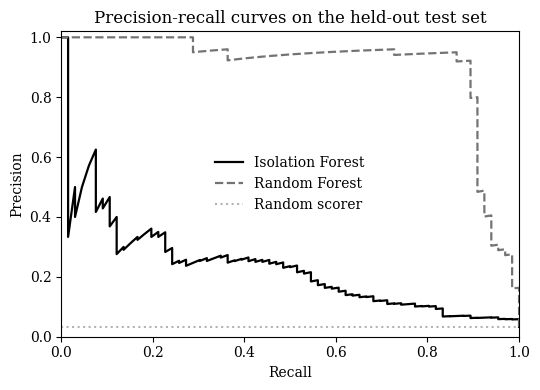


Saved: model_bundle.joblib, metrics.json, pr_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import json
import joblib
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score,
                             precision_recall_curve, confusion_matrix)

DB_PATH = "/content/maintenance.db"
RANDOM_STATE = 42
FALSE_ALARM_RATE = 0.05   # share of NORMAL records allowed to trigger an alert

FEATURES = ["type_code", "air_temperature", "process_temperature", "temp_diff",
            "rotational_speed", "torque", "tool_wear", "power_w", "strain"]

conn = sqlite3.connect(DB_PATH)

# ---------- 1. Inspect the 27 inconsistent labels ----------
print("Label consistency (machine_failure vs. any failure mode):")
display(pd.read_sql_query("""
    SELECT f.machine_failure,
           MAX(f.twf, f.hdf, f.pwf, f.osf, f.rnf) AS any_mode,
           COUNT(*) AS n_rows
    FROM failures f
    GROUP BY 1, 2
    ORDER BY 1, 2
""", conn))

# ---------- 2. Load features from SQL, excluding inconsistent rows ----------
CLEAN_QUERY = """
SELECT
    r.udi,
    CASE r.type WHEN 'L' THEN 0 WHEN 'M' THEN 1 ELSE 2 END      AS type_code,
    r.air_temperature,
    r.process_temperature,
    r.process_temperature - r.air_temperature                   AS temp_diff,
    r.rotational_speed,
    r.torque,
    r.tool_wear,
    r.torque * r.rotational_speed * 2 * 3.141592653589793 / 60  AS power_w,
    r.torque * r.tool_wear                                      AS strain,
    f.machine_failure
FROM readings r
JOIN failures f USING (udi)
WHERE f.machine_failure = MAX(f.twf, f.hdf, f.pwf, f.osf, f.rnf)
ORDER BY r.udi
"""
data = pd.read_sql_query(CLEAN_QUERY, conn)
conn.close()
print(f"\nRows kept: {len(data)}  (excluded {10000 - len(data)} inconsistent rows)")
print(f"Failure rate in kept rows: {100 * data['machine_failure'].mean():.2f}%")

X = data[FEATURES]
y = data["machine_failure"]

# ---------- 3. Split ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

# ---------- 4. Isolation Forest: fit on normal data only ----------
X_normal = X_train[y_train == 0]
X_fit, X_cal = train_test_split(X_normal, test_size=0.2, random_state=RANDOM_STATE)

iso = IsolationForest(n_estimators=300, contamination="auto",
                      random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(X_fit)

def anomaly_score(model, frame):
    return -model.score_samples(frame)   # higher = more anomalous

# Threshold calibrated on held-out NORMAL records (no failure labels needed)
cal_scores = anomaly_score(iso, X_cal)
threshold = float(np.quantile(cal_scores, 1 - FALSE_ALARM_RATE))

iso_test_scores = anomaly_score(iso, X_test)
iso_pred = (iso_test_scores >= threshold).astype(int)

# ---------- 5. Supervised baseline ----------
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample",
                            min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
rf_test_scores = rf.predict_proba(X_test)[:, 1]
rf_pred = (rf_test_scores >= 0.5).astype(int)

# ---------- 6. Evaluate ----------
def evaluate(name, y_true, score, pred):
    return {
        "model": name,
        "roc_auc": roc_auc_score(y_true, score),
        "avg_precision": average_precision_score(y_true, score),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
    }

results = pd.DataFrame([
    evaluate("Isolation Forest (normal-only, unsupervised)", y_test, iso_test_scores, iso_pred),
    evaluate("Random Forest (supervised baseline)", y_test, rf_test_scores, rf_pred),
]).round(3)

print(f"\nTest set: {len(y_test)} rows, {int(y_test.sum())} failures "
      f"(a random scorer would reach average precision of about {y_test.mean():.3f})")
print(f"Isolation Forest threshold (5% false-alarm rate on normal data): {threshold:.4f}\n")
display(results)

for name, pred in [("Isolation Forest", iso_pred), ("Random Forest", rf_pred)]:
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f"{name}: TN={tn} FP={fp} FN={fn} TP={tp}")

# ---------- 7. Precision-recall figure (grayscale, serif) ----------
plt.rcParams["font.family"] = "serif"
fig, ax = plt.subplots(figsize=(5.5, 4))
for label, scores, style in [("Isolation Forest", iso_test_scores, "-"),
                             ("Random Forest", rf_test_scores, "--")]:
    p, r, _ = precision_recall_curve(y_test, scores)
    ax.plot(r, p, style, color="black" if style == "-" else "0.45",
            linewidth=1.6, label=label)
ax.axhline(y_test.mean(), color="0.7", linestyle=":", label="Random scorer")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-recall curves on the held-out test set")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("/content/pr_curves.png", dpi=200)
plt.show()

# ---------- 8. Export artefacts for the Flask app ----------
bundle = {
    "iforest": iso,
    "rf": rf,
    "features": FEATURES,
    "if_threshold": threshold,
    "false_alarm_rate": FALSE_ALARM_RATE,
}
joblib.dump(bundle, "/content/model_bundle.joblib")
results.to_json("/content/metrics.json", orient="records", indent=2)
print("\nSaved: model_bundle.joblib, metrics.json, pr_curves.png")

try:
    from google.colab import files
    for f in ["model_bundle.joblib", "metrics.json", "pr_curves.png", "maintenance.db"]:
        files.download(f"/content/{f}")
except Exception as e:
    print("Download manually from the Colab file browser:", e)

## 4. Recall by failure mode

In [6]:
conn = sqlite3.connect(DB_PATH)
modes = pd.read_sql_query("SELECT udi, twf, hdf, pwf, osf, rnf FROM failures", conn)
conn.close()

test_meta = data.loc[X_test.index, ["udi"]].merge(modes, on="udi", how="left")
test_meta["if_alert"] = iso_pred
test_meta["rf_alert"] = rf_pred

mode_names = {"twf": "Tool wear", "hdf": "Heat dissipation", "pwf": "Power",
              "osf": "Overstrain", "rnf": "Random"}
rows = []
for col, name in mode_names.items():
    sub = test_meta[test_meta[col] == 1]
    rows.append({
        "failure_mode": name,
        "n_in_test_set": len(sub),
        "isolation_forest_recall": sub["if_alert"].mean() if len(sub) else float("nan"),
        "random_forest_recall": sub["rf_alert"].mean() if len(sub) else float("nan"),
    })
by_mode = pd.DataFrame(rows).round(2)
display(by_mode)

,failure_mode,n_in_test_set,isolation_forest_recall,random_forest_recall
0,Tool wear,7,0.00,0.00
1,Heat dissipation,25,0.12,0.96
2,Power,16,0.69,1.00
3,Overstrain,21,0.62,1.00
4,Random,0,NaN,NaN


In [7]:
import sklearn, pandas, numpy
print("scikit-learn", sklearn.__version__)
print("pandas", pandas.__version__)
print("numpy", numpy.__version__)

scikit-learn 1.6.1
pandas 2.2.3
numpy 2.1.3
